# 1. Installation

## 1.1 Python modules

In [1]:
import sys

if 'google.colab' in sys.modules:
    !pip install obspy obsplus pyproj segyio

## 1.2. Clone Field Camp II Library (fc2)

In [2]:
!git clone https://github.com/ecastillot/FieldCampII_2025.git /content/FieldCampII_2025

Cloning into '/content/FieldCampII_2025'...
remote: Enumerating objects: 427, done.
remote: Counting objects: 100% (188/188), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 427 (delta 106), reused 158 (delta 77), pack-reused 239 (from 1)
Receiving objects: 100% (427/427), 658.99 MiB | 23.50 MiB/s, done.
Resolving deltas: 100% (149/149), done.
Updating files: 100% (257/257), done.


In [3]:
import sys
lib = "/content/FieldCampII_2025"
sys.path.append(lib)

# 1.3. Test

In [4]:
from obspy import UTCDateTime # obspy
from fc2.seismic import read_shots_from_folder,plot_shot_data #fc2

# 2. Download data

Change the dropbox path to download the shots data

In [5]:
!wget -O project.zip "https://www.dropbox.com/scl/fo/8p6cqo5rr6qwaxpyn4zx9/AOiirDBEIFrZqV0-EMqkgzQ?rlkey=nwz9kl2hyyhlu2bkuqps1qdwo&dl=1"
!unzip  project.zip -d  project

--2025-06-23 19:46:50--  https://www.dropbox.com/scl/fo/8p6cqo5rr6qwaxpyn4zx9/AOiirDBEIFrZqV0-EMqkgzQ?rlkey=nwz9kl2hyyhlu2bkuqps1qdwo&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc73ab3aa109b34fc3bb8410354f.dl.dropboxusercontent.com/zip_download_get/CPlh64m0AuaTVQvOcSrJxByWmi8xTYGEARy936RV9EEB2o6k8Ei6c58WLqYOjBmP_Ks4nRcDRzt_ckhamJGPxgGvr2EcbR2e6F7gGRtcBA3UiQ# [following]
--2025-06-23 19:46:51--  https://uc73ab3aa109b34fc3bb8410354f.dl.dropboxusercontent.com/zip_download_get/CPlh64m0AuaTVQvOcSrJxByWmi8xTYGEARy936RV9EEB2o6k8Ei6c58WLqYOjBmP_Ks4nRcDRzt_ckhamJGPxgGvr2EcbR2e6F7gGRtcBA3UiQ
Resolving uc73ab3aa109b34fc3bb8410354f.dl.dropboxusercontent.com (uc73ab3aa109b34fc3bb8410354f.dl.dropboxusercontent.com)... 162.125.2.15, 2620:100:6017:15::a27d:20f
Connecting to uc73ab3aa109b34fc3bb8410354f.dl.d

# 3. Read data

## 3.1 Shots

In [6]:
help(read_shots_from_folder)

Help on function read_shots_from_folder in module fc2.seismic:

read_shots_from_folder(folder_path: str, gps_start=None, source_time_separation=None, bad_shots=None, debug=False) -> pandas.core.frame.DataFrame
    Reads all shot files in a specified folder and merges them into a single DataFrame.
    Parameters
    ----------
    folder_path : str
        Path to the folder containing shot files.
    gps_start : datetime.datetime or None
        The GPS epoch start time. If None, defaults to January 6, 1980.
    source_time_separation : dict
        The maximum time separation between shots to consider them part of the same group (in seconds).
        example: {"P1": 76.45, "S1_N": 21, ...}
    bad_shots : list or None
        A list of shot groups to exclude from the final DataFrame. If None, all shots are included.
    debug : bool
        If True, prints debug information during processing.
    Returns
    -------
    pd.DataFrame
        A DataFrame containing all shots, sorted by 

In [17]:
project_folder = "/content/project/Big_Road_B"

shots = read_shots_from_folder(project_folder)
display(shots)


Group 'last_group' with 168 shots


/content/FieldCampII_2025/fc2/seismic.py:382: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gd_shots = pd.concat([gd_shots, bad_shots]).reset_index(drop=True)


,shot_group,shot,time,time_from_group_lead,year,month,day,hour,minute,second,latitude,longitude
0,last_group,1,2025-06-19 14:53:20.460,0.00,2025,6,19,14,53,20.46,27.29899,-97.35566
1,last_group,2,2025-06-19 14:53:46.880,26.42,2025,6,19,14,53,46.88,27.29899,-97.35566
2,last_group,3,2025-06-19 14:54:17.710,57.25,2025,6,19,14,54,17.71,27.29900,-97.35566
3,last_group,4,2025-06-19 14:55:14.860,114.40,2025,6,19,14,55,14.86,27.29901,-97.35570
4,last_group,5,2025-06-19 14:55:35.930,135.47,2025,6,19,14,55,35.93,27.29902,-97.35570
...,...,...,...,...,...,...,...,...,...,...,...,...
163,last_group,164,2025-06-19 16:08:07.660,4487.20,2025,6,19,16,8,7.66,27.29878,-97.35490
164,last_group,165,2025-06-19 16:08:29.640,4509.18,2025,6,19,16,8,29.64,27.29878,-97.35490
165,last_group,166,2025-06-19 16:08:38.040,4517.58,2025,6,19,16,8,38.04,27.29878,-97.35490
166,last_group,167,2025-06-19 16:08:44.050,4523.59,2025,6,19,16,8,44.05,27.29878,-97.35489


We need to label each group

In [18]:
display(shots.iloc[0:15])

,shot_group,shot,time,time_from_group_lead,year,month,day,hour,minute,second,latitude,longitude
0,last_group,1,2025-06-19 14:53:20.460,0.00,2025,6,19,14,53,20.46,27.29899,-97.35566
1,last_group,2,2025-06-19 14:53:46.880,26.42,2025,6,19,14,53,46.88,27.29899,-97.35566
2,last_group,3,2025-06-19 14:54:17.710,57.25,2025,6,19,14,54,17.71,27.29900,-97.35566
3,last_group,4,2025-06-19 14:55:14.860,114.40,2025,6,19,14,55,14.86,27.29901,-97.35570
4,last_group,5,2025-06-19 14:55:35.930,135.47,2025,6,19,14,55,35.93,27.29902,-97.35570
5,last_group,6,2025-06-19 14:55:58.050,157.59,2025,6,19,14,55,58.05,27.29902,-97.35570
6,last_group,7,2025-06-19 14:57:56.750,276.29,2025,6,19,14,57,56.75,27.29901,-97.35569
7,last_group,8,2025-06-19 14:58:12.870,292.41,2025,6,19,14,58,12.87,27.29901,-97.35569
8,last_group,9,2025-06-19 14:58:17.690,297.23,2025,6,19,14,58,17.69,27.29901,-97.35570
9,last_group,10,2025-06-19 14:58:21.620,301.16,2025,6,19,14,58,21.62,27.29901,-97.35570


In [57]:
source_time_separation = { #P Wave
                              "P1": 158,
                          "P2": 55,
                           "P3": 26,
                           "P4": 26,
                           "P5": 51,
                           "P6": 46,
                           "P7": 30,
                           "P8": 27,
                           "P9": 37,
                           "P10": 71,
                           "P11": 29,
                           "P12": 21,
                           "P13": 21,
                           "P14": 23,
                           "P15": 27,
                           "P16": 35,
                           "P17": 42,
                           "P18": 53,
                           "P19": 126,
                           "P20": 26,
                           "P21": 47,
                           "P22": 45,
                           "P23": 52,
                           "P24": 60,
                           "P25": 125,
                           "P26": 49,
                           "P27": 78,
                           "P28": 46}
shots = read_shots_from_folder(project_folder,
                               source_time_separation = source_time_separation,
                               debug=False)
display(shots.iloc[130:168])


Group P1 started at 2025-06-19 14:53:20.460000 with 6 shots

Group P2 started at 2025-06-19 14:57:56.750000 with 6 shots

Group P3 started at 2025-06-19 15:00:51.960000 with 6 shots

Group P4 started at 2025-06-19 15:01:59.430000 with 6 shots

Group P5 started at 2025-06-19 15:05:06.240000 with 6 shots

Group P6 started at 2025-06-19 15:07:43.250000 with 6 shots

Group P7 started at 2025-06-19 15:10:28.310000 with 6 shots

Group P8 started at 2025-06-19 15:12:46.120000 with 6 shots

Group P9 started at 2025-06-19 15:14:32.560000 with 6 shots

Group P10 started at 2025-06-19 15:28:45.070000 with 6 shots

Group P11 started at 2025-06-19 15:30:46.060000 with 6 shots

Group P12 started at 2025-06-19 15:32:12.190000 with 6 shots

Group P13 started at 2025-06-19 15:33:14.850000 with 6 shots

Group P14 started at 2025-06-19 15:34:33.850000 with 6 shots

Group P15 started at 2025-06-19 15:35:37.110000 with 6 shots

Group P16 started at 2025-06-19 15:37:26.860000 with 6 shots

Group P17 starte

,shot_group,shot,time,time_from_group_lead,year,month,day,hour,minute,second,latitude,longitude
130,P22,131,2025-06-19 15:50:39.660,37.44,2025,6,19,15,50,39.66,27.29882,-97.35507
131,P22,132,2025-06-19 15:50:46.270,44.05,2025,6,19,15,50,46.27,27.29882,-97.35506
132,P23,133,2025-06-19 15:53:23.020,0.00,2025,6,19,15,53,23.02,27.29882,-97.35505
133,P23,134,2025-06-19 15:53:29.300,6.28,2025,6,19,15,53,29.30,27.29882,-97.35505
134,P23,135,2025-06-19 15:53:33.950,10.93,2025,6,19,15,53,33.95,27.29882,-97.35505
135,P23,136,2025-06-19 15:53:52.440,29.42,2025,6,19,15,53,52.44,27.29882,-97.35505
136,P23,137,2025-06-19 15:54:06.770,43.75,2025,6,19,15,54,6.77,27.29882,-97.35506
137,P23,138,2025-06-19 15:54:14.050,51.03,2025,6,19,15,54,14.05,27.29882,-97.35506
138,P24,139,2025-06-19 15:55:29.670,0.00,2025,6,19,15,55,29.67,27.29882,-97.35506
139,P24,140,2025-06-19 15:55:56.100,26.43,2025,6,19,15,55,56.10,27.29882,-97.35505


Plot saved to shots_plot.png


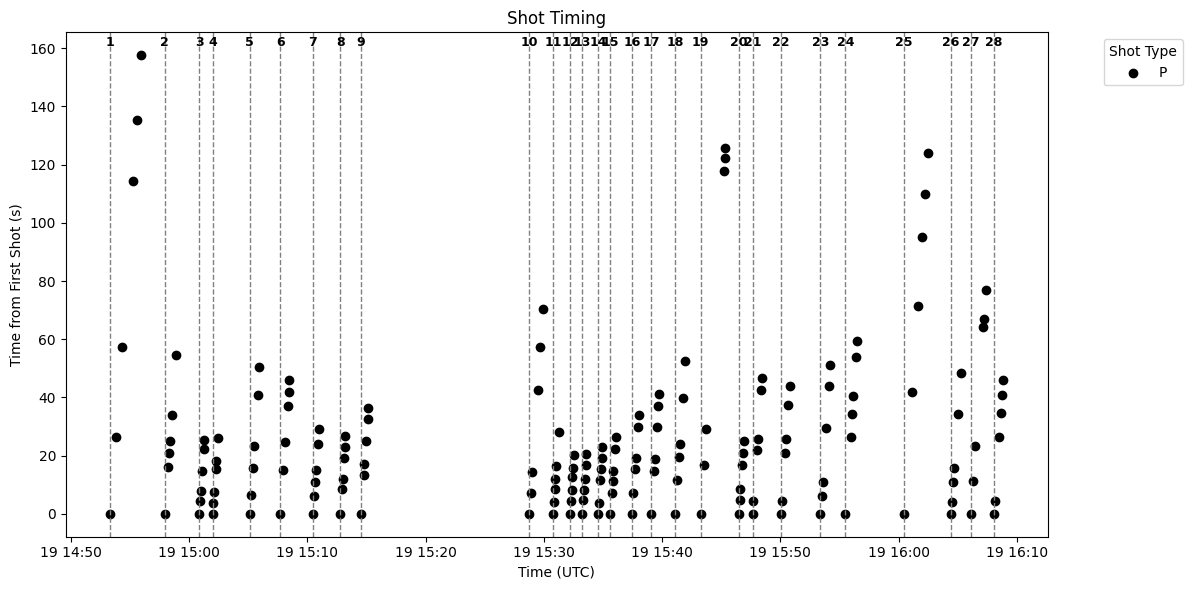

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Shot Timing'}, xlabel='Time (UTC)', ylabel='Time from First Shot (s)'>)

In [58]:
out_path = "shots_plot.png"
shots.to_csv("shots_labeled.csv",index=False)
plot_shot_data(shots, save_path=out_path, show=True)